### Logistic Regression 



In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


In [36]:
df = pd.read_csv("e-com_cleaned_dataset.csv")
df.head()


,Order_ID,Customer_ID,Order_Date,Customer_Age,Customer_Segment,City,Region,Category,Product_Name,Sales_Channel,...,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
0,ORD100994,C1229,2025-06-07,44.0,Occasional,Delhi,Central,Sports,Shoes,Online,...,16.4,10,10,1.8,723.34,0.00,723.34,634.67,88.67,12.26
1,ORD101072,C1627,2025-03-18,51.0,Occasional,Kochi,West,Home Appliances,Shoes,Online,...,23.2,9,3,5.0,2639.48,328.29,2285.92,1613.24,612.14,28.36
2,ORD100995,C1410,2025-07-13,35.0,Occasional,Hyderabad,West,Electronics,Laptop,Online,...,9.1,10,6,3.0,739.05,105.68,633.37,370.35,263.02,41.53
3,ORD100731,C1578,2025-09-24,38.0,Regular,Bengaluru,North,Fashion,Shoes,Mobile App,...,22.7,4,4,3.6,28004.44,1473.03,26531.41,17911.62,8619.79,32.49
4,ORD102954,C1524,2025-06-09,39.0,Premium,Kolkata,South,Electronics,Skincare,Marketplace,...,6.6,8,8,2.5,9841.78,1842.38,7999.40,6214.63,1784.77,22.31


In [37]:
df.shape


(2852, 32)

In [38]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2852 entries, 0 to 2851
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_ID                 2852 non-null   object 
 1   Customer_ID              2852 non-null   object 
 2   Order_Date               2852 non-null   object 
 3   Customer_Age             2852 non-null   float64
 4   Customer_Segment         2852 non-null   object 
 5   City                     2852 non-null   object 
 6   Region                   2852 non-null   object 
 7   Category                 2852 non-null   object 
 8   Product_Name             2852 non-null   object 
 9   Sales_Channel            2852 non-null   object 
 10  Payment_Method           2852 non-null   object 
 11  Device                   2852 non-null   object 
 12  Quantity                 2852 non-null   int64  
 13  Unit_Price               2852 non-null   float64
 14  Discount_Pct            

In [39]:
df.describe(include="all")


,Order_ID,Customer_ID,Order_Date,Customer_Age,Customer_Segment,City,Region,Category,Product_Name,Sales_Channel,...,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
count,2852,2852,2852,2852.000000,2852,2852,2852,2852,2852,2852,...,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000
unique,2852,774,365,NaN,4,10,5,8,10,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,ORD101347,C1744,2025-12-08,NaN,Regular,Chennai,East,Home Appliances,Novel,Store,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,10,20,NaN,1390,308,590,409,319,816,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,35.404278,NaN,NaN,NaN,NaN,NaN,NaN,...,14.677139,7.043829,5.004909,3.665288,5138.416476,753.366189,4285.255754,3064.366655,1213.317921,28.352048
std,NaN,NaN,NaN,11.137747,NaN,NaN,NaN,NaN,NaN,NaN,...,9.469406,2.661515,2.289158,0.821690,9061.894474,1654.471979,7458.582159,5250.740997,2484.419099,9.018859
min,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-1394.000000,12.040000
25%,NaN,NaN,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,8.000000,5.000000,3.000000,3.100000,1253.302500,119.872500,1097.265000,785.170000,293.767500,20.845000
50%,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,12.700000,7.000000,5.000000,3.700000,2639.480000,328.290000,2285.920000,1613.240000,612.140000,28.360000
75%,NaN,NaN,NaN,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,19.300000,9.000000,6.000000,4.300000,5578.300000,749.090000,4472.040000,3205.825000,1225.102500,35.602500


In [40]:
df.isnull().sum()


Order_ID                   0
Customer_ID                0
Order_Date                 0
Customer_Age               0
Customer_Segment           0
City                       0
Region                     0
Category                   0
Product_Name               0
Sales_Channel              0
Payment_Method             0
Device                     0
Quantity                   0
Unit_Price                 0
Discount_Pct               0
Shipping_Days              0
Customer_Rating            0
Delivery_Rating            0
Return_Status              0
Order_Status               0
Marketing_Source           0
Customer_Loyalty_Points    0
Website_Session_Minutes    0
Items_Viewed               0
Previous_Orders            0
Customer_Satisfaction      0
Gross_Amount               0
Discount_Amount            0
Net_Sales                  0
Estimated_Cost             0
Profit                     0
Profit_Margin_Pct          0
dtype: int64

In [41]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Customer_Age',
       'Customer_Segment', 'City', 'Region', 'Category', 'Product_Name',
       'Sales_Channel', 'Payment_Method', 'Device', 'Quantity', 'Unit_Price',
       'Discount_Pct', 'Shipping_Days', 'Customer_Rating', 'Delivery_Rating',
       'Return_Status', 'Order_Status', 'Marketing_Source',
       'Customer_Loyalty_Points', 'Website_Session_Minutes', 'Items_Viewed',
       'Previous_Orders', 'Customer_Satisfaction', 'Gross_Amount',
       'Discount_Amount', 'Net_Sales', 'Estimated_Cost', 'Profit',
       'Profit_Margin_Pct'],
      dtype='object')

In [42]:
df["Sales_Class"] = (df["Net_Sales"] >= df["Net_Sales"].median()).astype(int)

In [43]:
target = "Sales_Class"

In [44]:
Y = df[["Return_Status"]].copy()
X = df.drop(columns=["Return_Status"]).copy()



`X` contains the independent/input features. `Y` contains the dependent/target variable `Return_Status`.

In [45]:
Y.value_counts()


Return_Status
No               2473
Yes               379
Name: count, dtype: int64

In [46]:
Y.value_counts(normalize=True)


Return_Status
No               0.867111
Yes              0.132889
Name: proportion, dtype: float64

In [47]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()


In [ ]:
X[numeric_features].hist(figsize=(14, 10))
plt.tight_layout()


: 

: 

In [ ]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()

In [ ]:
df[numeric_features + [target]].corr(numeric_only=True)

,Customer_Age,Quantity,Unit_Price,Discount_Pct,Shipping_Days,Customer_Rating,Delivery_Rating,Customer_Loyalty_Points,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct,Sales_Class,Sales_Class
Customer_Age,1.000000,-0.013159,-0.007446,0.021526,0.015767,-0.021683,-0.009516,0.028472,0.001773,-0.011933,-0.009584,-0.008412,-0.005167,-0.011590,-0.001501,-0.002253,-0.000148,-0.009516,-0.035115,-0.035115
Quantity,-0.013159,1.000000,0.009911,0.018102,-0.007152,-0.000642,-0.008338,0.002442,0.007104,-0.011837,0.000937,0.037970,0.321782,0.288305,0.322330,0.337054,0.255472,-0.014781,0.274810,0.274810
Unit_Price,-0.007446,0.009911,1.000000,-0.011390,-0.018198,-0.008234,0.022207,-0.003289,0.005057,0.004765,-0.025820,-0.010814,0.874134,0.693698,0.820237,0.790738,0.791403,0.006978,0.385809,0.385809
Discount_Pct,0.021526,0.018102,-0.011390,1.000000,-0.007274,0.027833,0.011069,-0.006429,0.006916,0.001935,0.007796,0.004880,-0.009787,0.266636,-0.070684,-0.067294,-0.069843,-0.032451,-0.094630,-0.094630
Shipping_Days,0.015767,-0.007152,-0.018198,-0.007274,1.000000,0.011705,0.021503,0.027548,0.005474,-0.002422,-0.000512,0.009753,-0.022152,-0.028835,-0.021988,-0.018986,-0.026150,-0.027942,-0.016681,-0.016681
Customer_Rating,-0.021683,-0.000642,-0.008234,0.027833,0.011705,1.000000,0.018396,0.011773,-0.011569,-0.006535,0.014940,0.000906,-0.006670,0.010942,-0.008825,-0.012143,-0.000628,0.004319,0.004714,0.004714
Delivery_Rating,-0.009516,-0.008338,0.022207,0.011069,0.021503,0.018396,1.000000,0.013246,-0.002221,0.024554,-0.020763,-0.017228,0.012482,0.007354,0.013572,0.011153,0.016784,-0.019280,0.005209,0.005209
Customer_Loyalty_Points,0.028472,0.002442,-0.003289,-0.006429,0.027548,0.011773,0.013246,1.000000,0.053664,-0.006068,0.014955,-0.007801,-0.004329,-0.011564,-0.006623,-0.005644,-0.007596,0.008428,0.006098,0.006098
Website_Session_Minutes,0.001773,0.007104,0.005057,0.006916,0.005474,-0.011569,-0.002221,0.053664,1.000000,0.026592,0.000725,0.021893,0.001472,0.003249,0.002773,0.007039,-0.006602,-0.026417,0.006512,0.006512
Items_Viewed,-0.011933,-0.011837,0.004765,0.001935,-0.002422,-0.006535,0.024554,-0.006068,0.026592,1.000000,-0.020012,-0.018518,0.014887,0.034228,0.020611,0.014831,0.030255,-0.015229,-0.010324,-0.010324


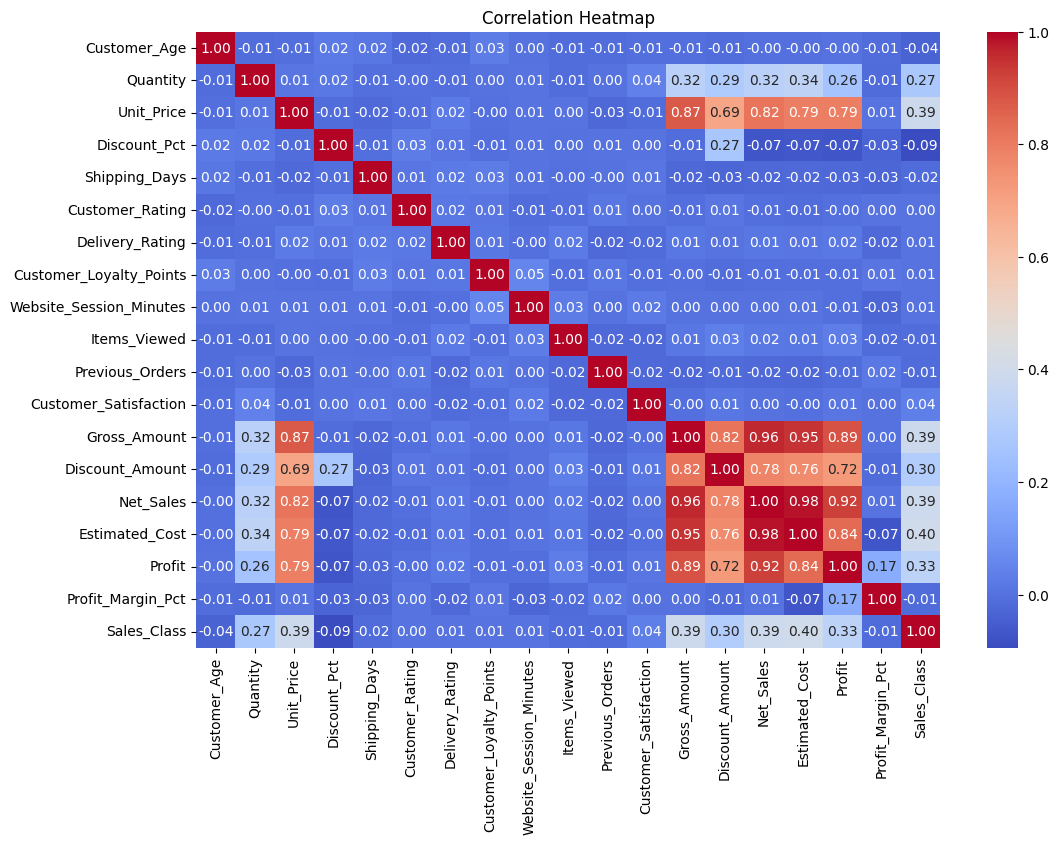

In [ ]:
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features)
])


In [ ]:
train_x, test_x, train_y, test_y = train_test_split(
    X, Y["Return_Status"], test_size=0.2, random_state=42, stratify=Y["Return_Status"]
)


In [ ]:
train_x.shape, test_x.shape, train_y.shape, test_y.shape


((2281, 32), (571, 32), (2281,), (571,))

### LogisticRegression

In [ ]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(train_x, train_y)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Customer_Age', 'Quantity',
                                                   'Unit_Price', 'Discount_Pct',
                                                   'Shipping_Days',
                                                   'Customer_Rating',
                                                   'Delivery_Rating',
                                                   'Customer_Loyalty_Points',
                                                   'Website_Session_Minutes',
                                                   'Items_Viewed',
                                                   'Previous_Orde...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Order_ID', 'Customer_ID',
                                                   'Order_Date',
                                                   'Customer_Segment', 'City',
                                                   'Region', 'Category',
                                                   'Product_Name',
                                                   'Sales_Channel',
                                                   'Payment_Method', 'Device',
                                                   'Order_Status',
                                                   'Marketing_Source'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
pred_y = model.predict(test_x)
pred_probability = model.predict_proba(test_x)[:, 1]


In [ ]:
accuracy = accuracy_score(test_y, pred_y)
precision = precision_score(test_y, pred_y, pos_label="Yes")
recall = recall_score(test_y, pred_y, pos_label="Yes")
f1 = f1_score(test_y, pred_y, pos_label="Yes")
roc_auc = roc_auc_score((test_y == "Yes").astype(int), (pred_y == "Yes").astype(int))

print("\nModel Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Model Performance:
Accuracy: 0.8634
Precision: 0.2500
Recall: 0.0132
F1 Score: 0.0250


In [ ]:
confusion_matrix(test_y, pred_y)


array([[492,   3],
       [ 75,   1]])

The confusion matrix shows True Positives, True Negatives, False Positives, and False Negatives.

In [ ]:
print("\nModel Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")



Model Performance:
Accuracy: 0.8634
Precision: 0.2500
Recall: 0.0132
F1 Score: 0.0250
ROC-AUC Score: 0.5035


In [ ]:
print(classification_report(test_y, pred_y, zero_division=0))


              precision    recall  f1-score   support

          No       0.87      0.99      0.93       495
         Yes       0.25      0.01      0.03        76

    accuracy                           0.86       571
   macro avg       0.56      0.50      0.48       571
weighted avg       0.79      0.86      0.81       571



### DecisionTree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

In [ ]:
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

In [ ]:
dt_model.fit(train_x, train_y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Customer_Age', 'Quantity',
                                                   'Unit_Price', 'Discount_Pct',
                                                   'Shipping_Days',
                                                   'Customer_Rating',
                                                   'Delivery_Rating',
                                                   'Customer_Loyalty_Points',
                                                   'Website_Session_Minutes',
                                                   'Items_Viewed',
                                                   'Previous_Orde...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Order_ID', 'Customer_ID',
                                                   'Order_Date',
                                                   'Customer_Segment', 'City',
                                                   'Region', 'Category',
                                                   'Product_Name',
                                                   'Sales_Channel',
                                                   'Payment_Method', 'Device',
                                                   'Order_Status',
                                                   'Marketing_Source'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [ ]:
dt_pred_y = dt_model.predict(test_x)

dt_pred_probability = dt_model.predict_proba(test_x)[:, 1]

Confusion Matrix:
[[494   1]
 [ 76   0]]


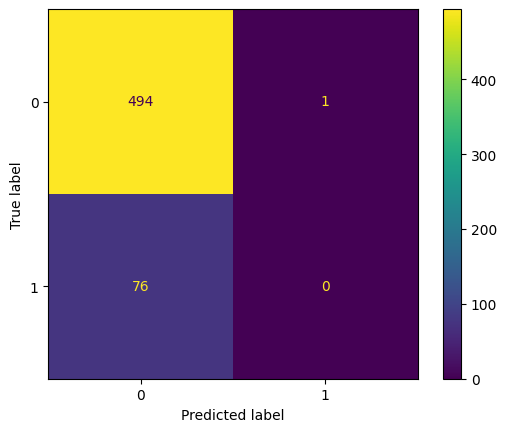

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
dt_cm = confusion_matrix(test_y, dt_pred_y)
print("Confusion Matrix:")
print(dt_cm)
ConfusionMatrixDisplay(confusion_matrix=dt_cm).plot()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(test_y, dt_pred_y))

              precision    recall  f1-score   support

          No       0.87      1.00      0.93       495
         Yes       0.00      0.00      0.00        76

    accuracy                           0.87       571
   macro avg       0.43      0.50      0.46       571
weighted avg       0.75      0.87      0.80       571



In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

dt_accuracy = accuracy_score(test_y, dt_pred_y)
dt_precision = precision_score(test_y, dt_pred_y, pos_label="Yes", zero_division=0)
dt_recall = recall_score(test_y, dt_pred_y, pos_label="Yes", zero_division=0)
dt_f1 = f1_score(test_y, dt_pred_y, pos_label="Yes", zero_division=0)
dt_roc_auc = roc_auc_score(
    (test_y == "Yes").astype(int),
    dt_pred_probability
)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)
print("ROC-AUC  :", dt_roc_auc)

Decision Tree Results
---------------------
Accuracy : 0.8651488616462347
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.498989898989899
